**Problems: Kernal Density Estimation**

Author: Eric J. Hoerdemann

**Problem 1**

In [21]:
# Imports as usual
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import math as m
from scipy.stats import norm

**a) Sketch the empirical cumulative distribution function.**

[Text(0.5, 1.0, 'ECDF Plot')]


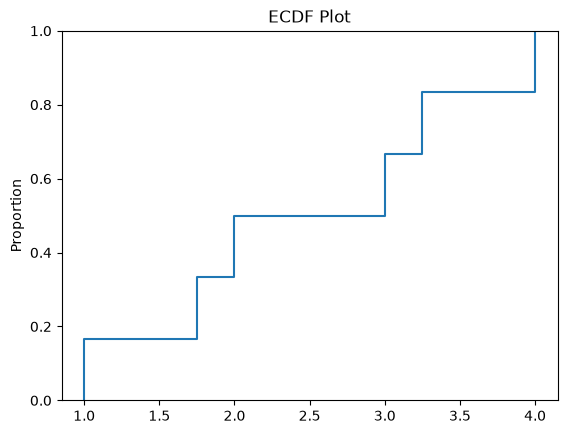

In [5]:
# ECDF plot
data = [1, 1.75, 2, 3, 3.25, 4]
ecdf_plot = sns.ecdfplot(data).set(title='ECDF Plot')
print(ecdf_plot)

**b) Sketch the uniform kernel density estimator for a bandwidth of h = 0.2**

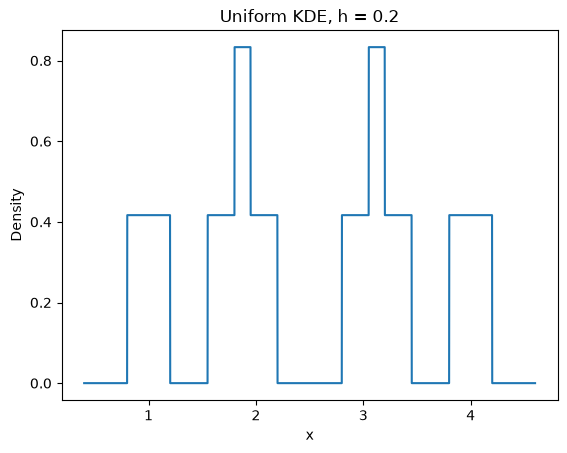

In [7]:
# Cannot get uniform KDE using seaborn, so have to use other option
# I did not know how to do this, so I used Claude Opus 5.5 to help me, and it told me to use statsmodels
kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="uni", bw=0.2, fft=False, gridsize=5000)

plt.plot(kde.support, kde.density)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Uniform KDE, h = 0.2")
plt.show()

**c) Compute the Silverman bandwidth for the uniform kernel using h = 1.84 * SD * n**(-0.2)**

In [ ]:
sample_mean = sum(data)/len(data)
rss = 0
for data_point in data:
    new_res = (data_point - sample_mean)**2
    rss += new_res
sd = m.sqrt(rss/(len(data) - 1))

# Compute h
h = 1.84 * sd * (len(data))**(-0.2)
print(f"Silverman's Bandwith: ~{h:.3}")

Silverman's Bandwith: ~1.42


**d) Sketch the uniform kernel density estimator for the Silverman bandwidth.**

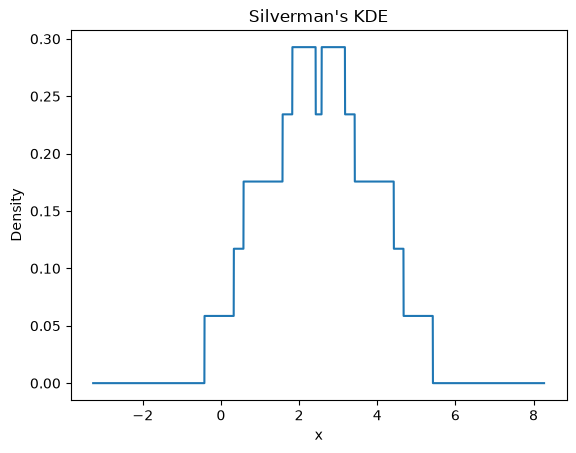

In [18]:
# Recycle code from above, just changing bandwidth
kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="uni", bw=h, fft=False, gridsize=5000)

plt.plot(kde.support, kde.density)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Silverman's KDE")
plt.show()

**e) How are b and d similar or different?**

The similarity between the two stems from the fact that they are both doing the same thing, that is, estimating the probability density function on a small set of data. With bandwidth 0.2, the boxes are larger, and there is more space between them (no stacking) which is not ideal considering some data point x=2.5 for example would likely exist in the real distribution that we are estimating.Larger boxes means higher variance. SO it misrepresents the data.

The Silverman's plot uses a lower bandwidth, and smaller boxes so it appears that it is doing a better job of reflecting the data. In reality, the Silverman's plot actually overfits/oversmooths the data, which leads to a higher bias than the other model, even though the variance is decreased. This is the tradeoff we discussed in class.

**Problem 2**

**Suppose the data X = [-1, -0.5, 0, 0.5, 1] were drawn from a standard Normal distribution.**

**a) Using the uniform kernel with h = 0.6, compute the realized KDE at x = 0, f_hat_h(0), directly from these five numbers.**

In [20]:
# Recycle the code from above, now redefining the data
data = [-1, -0.5, 0, 0.5, 1]
h = 0.6
kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="uni", bw=h, fft=False, gridsize=5000)

# Compute the Realized KDE
print(f"Realized KDE at x=0, f_hat_h(0): {kde.evaluate(0)}")

Realized KDE at x=0, f_hat_h(0): [0.5]


**b) b. Now compute E[f_hat_h(0)] at the same h = 0.6.**

In [23]:
# Need to find the probability that X is between -0.6 and 0.6 and multiply that by the
# Derived formula that we have to use is E[f_hat_h(0)] = P/2h

# Note... I derived the formula that I used here by hand, starting with the formula for the KDE f(x), taking its expectation
#         and then using the laws/rules of expectation to arrive at the derived formula

denom = 2*h
p = norm.cdf(0.6) - norm.cdf(-0.6) # Note of AI Usage: did not know the module for finding this probability
f_hat_computed = p / denom

print(f"E[f_hat_h(0)] = ~{f_hat_computed:.3}")


E[f_hat_h(0)] = ~0.376


**c) Calculate the true density at x=0, using the Normal distribution.**

In [28]:
# Use formula for standard normal density...
# f(x) = (1 / √(2π)) x e^(−x²/2) (Obtained this using google)

f = (1/(m.sqrt(2*(m.pi)))) * m.exp(0/2)
print(f"True Density at x=0: ~{f:.3}")

True Density at x=0: ~0.399


**d) Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare E[f_hat_h] to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)**

In [30]:
bias = f-f_hat_computed
print(f"Bias: ~{bias:.3}")

Bias: ~0.0227


No b and c are not equal, and the KDE has a model bias of 0.0227, meaning that even when we average over all samples, the KDE is still not fully capturing the density across the distribution. This makes sense, as the true normal distribution cannot fully be captured by a kernal density estimation, hence why it is an estimation.

**e) Recompute E[f_hat_h(0)] from (b) at a much smaller bandwidth, h = 0.1. What happens to the gap between E[f_hat_h(0)] and f(0) as h shrinks?**

In [31]:
# Recycled code from part b
h = 0.1
denom = 2*h
p = norm.cdf(h) - norm.cdf(-h) # Note of AI Usage: did not know the module for finding this probability
f_hat_computed = p / denom

print(f"E[f_hat_h(0)] = ~{f_hat_computed:.3}")

E[f_hat_h(0)] = ~0.398


As h shrinks the gap gets smaller.

**f) Is f_hat_h a consistent estimator? Explain your reasoning.**

A consistent estimator is one that approaches the true value as larger heaps of data are collected and lower bandwidths are used. So it is consistent when the right set of parameters are used.

**g) What are the main considerations in choosing a bandwidth value h**

The bias variance tradeoff is the main point of consideration. A small h gives low bias but high variance, meaning that the estimates drastically change from sample to sample. The sample size, the shape of the data, and the scale of the data are also important to consider, and they all logically stem from the bias variance tradeoff.

**Problem 3**

**Suppose the data are X = [5, 7, 7, 8, 10], and fix the bandwidth at h = 1.5 for both kernels below.**

**a) Compute the uniform-kernel KDE, f_hat_h(x), at x = 6.0, x = 6.5, x = 7.0, x = 8.0, and x = 8.5.**

In [32]:
data = [5,7,7,8,10]
h = 1.5
kde = sm.nonparametric.KDEUnivariate(data)
kde.fit(kernel="uni", bw=h, fft=False, gridsize=5000)
print(f"f_hat_h(x) at x = 6.0: {kde.evaluate(6.0)}")
print(f"f_hat_h(x) at x = 6.5: {kde.evaluate(6.5)}")
print(f"f_hat_h(x) at x = 7.0: {kde.evaluate(7.0)}")
print(f"f_hat_h(x) at x = 8.0: {kde.evaluate(8.0)}")
print(f"f_hat_h(x) at x = 8.5: {kde.evaluate(8.5)}")

f_hat_h(x) at x = 6.0: [0.2]
f_hat_h(x) at x = 6.5: [0.26666667]
f_hat_h(x) at x = 7.0: [0.2]
f_hat_h(x) at x = 8.0: [0.2]
f_hat_h(x) at x = 8.5: [0.26666667]


**b) Compute the Gaussian-kernel KDE at the same five values of x, using the same h = 1.5.**

In [33]:
# Note: I changed the first two lines of code from the uniform KDE above
kde_gau = sm.nonparametric.KDEUnivariate(data)
kde_gau.fit(kernel="gau", bw=h, fft=False)
print(f"f_hat_h(x) at x = 6.0: {kde_gau.evaluate(6.0)}")
print(f"f_hat_h(x) at x = 6.5: {kde_gau.evaluate(6.5)}")
print(f"f_hat_h(x) at x = 7.0: {kde_gau.evaluate(7.0)}")
print(f"f_hat_h(x) at x = 8.0: {kde_gau.evaluate(8.0)}")
print(f"f_hat_h(x) at x = 8.5: {kde_gau.evaluate(8.5)}")

f_hat_h(x) at x = 6.0: [0.15116668]
f_hat_h(x) at x = 6.5: [0.16865731]
f_hat_h(x) at x = 7.0: [0.17804448]
f_hat_h(x) at x = 8.0: [0.16744524]
f_hat_h(x) at x = 8.5: [0.15060231]


**c) Your part (a) values should jump abruptly between some of these five points, while your part (b) values should change smoothly. Identify where the biggest jump in (a) happens, and explain in terms of the two kernel shapes -- not just "one is smoother" -- why that jump exists in the uniform case but not the Gaussian case.**

There are 3 extreme jumps at x = 6.5 and x = 8.5 in part (a), all jump up or down by a height of 0.067. Each box in the uniform kernel is a rectangle with a chosen bandwidth and box height computed based on the height and size of the sample. Gaussian "boxes" on the other hand are bellcurved. As a result, not all points in a full density distribution are counted, if they are not in the bandwidth of a sample point, explaining the abrupt spikes. Using the Gaussian boxes, all points are accounted for as the bell curve tapers off by weight in the distance.

**d) Why might you prefer one kernel over the other in practice?**

Gaussian kernels are typically prefered in practice, due to the fact that they create smoother more realistic looking plots that better match the true distributions. Unform can be better in situations where something easily interpretable is prefered. Uniform unlike Gaussian can also be done by hand.

**Problem 4**

**Load ./data/heart_failure_clinical_records_dataset.csv.**

In [34]:
last_data = pd.read_csv("C:/users/ericj/DS5030/UU_F26_templates/Week04/data/heart_failure_clinical_records_dataset.csv")
last_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**a) Plot a kernel density estimate of ejection_fraction**

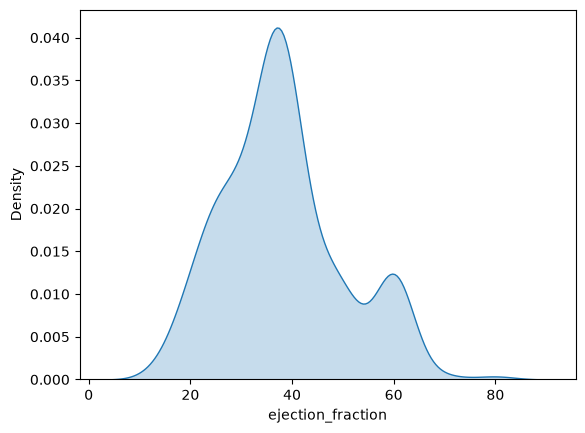

In [36]:
# Recycled from earlier class notebooks (seaborn code)
sns.kdeplot(data=last_data, x="ejection_fraction", fill=True)
plt.show()

**b) Use Pandas' df.sample(frac=1.0, replace=True) to resample the data 15 times with replacement, plotting the kernel density estimtes for each sample.**

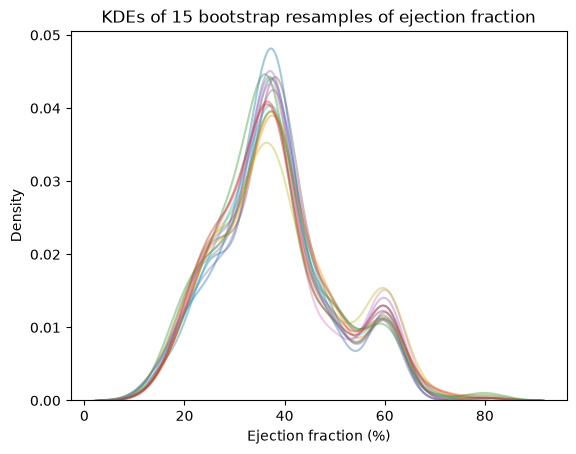

In [37]:
# Note of AI Usage: I did not know how to do this, although I believed it involved a for loop in some way. I used Claude Opus 5.5 to help me with the code structure for this.

for i in range(15):
    boot = last_data.sample(frac=1.0, replace=True)
    sns.kdeplot(data=boot, x="ejection_fraction", alpha=0.4)

plt.title("KDEs of 15 bootstrap resamples of ejection fraction")
plt.xlabel("Ejection fraction (%)")
plt.show()

**c) For what values of ejection_fraction is the original plot reliable? For which values is there noticeable variation in your plots of the resampled data?**

The original plot is reliable for values where the 15 density plots are layered as directly on top of one another as possible. The original plot is largely reliable for the tails of the graph, and does a decent job until they approach the peaks of the graph. The spots of noticeable variation are the peaks, as well as the values that lead up to the peaks.